## Statistics in Data Analysis


## Общая информация

Проект выполнен в рамках учебного модуля по дисциплине "Программирование Python"

Проект затрагивает практику A/B-тестирования, формирование и проверку статистических гипотез


**Суть задания / тз проекта**:

Данный групповой проект состоит из **двух частей**:

1. **A/B-тестирование**: анализ результатов эксперимента, которые зафиксированы в датасете `data_ab.csv`, — проверка наличия статистически и практически значимых различий между наблюдениями в контрольной и экспериментальной группах.
2. **Проверка гипотез на выбранном датасете**: выбор одного или нескольких датасетов с сайта [UCI Machine Learning Repository](https://archive.ics.uci.edu/) либо же получение соответствующих датасетов путем парсинга/работы с API; осуществление этапа первичного анализа данных (EDA); определение не менее трех содержательных гипотез *на основе проделанного EDA*; их проверка с помощью различнных статистических тестов.


## Project - part1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import ttest_ind, ttest_rel, chi2_contingency, shapiro, levene
from scipy import stats as scipy_stats
from datetime import datetime, timedelta
from statsmodels.stats.proportion import proportions_ztest

%matplotlib inline

### Часть 1. A/B-тест


####Информация о датасете:

Датасет состоит из пяти столбцов:

* `user_id` — уникальный идентификатор пользователя;

* `timestamp` — время посещения пользователем страницы;

* `group` — группа эксперимента, к которой был случайно отнесён пользователь:

  *   `control` — контрольная группа,
  *   `treatment` — экспериментальная группа;

* `landing_page` — версия лендинга, которую увидел пользователь:

  *   `old_page` — старая версия страницы,
  *   `new_page` — новая версия страницы;

* `converted` — бинарный признак, показывающий, совершил ли пользователь целевое действие (целевым действием является регистрация на курс).








По замыслу A/B-теста контрольной группе (`control`) должна была показываться старая версия лендинга — `old_page`; экспериментальной группе (`treatment`) должна была показываться новая версия лендинга — `new_page`.



#### Первичный осмотр данных

In [ ]:
df = pd.read_csv('data_ab.csv')
df

In [ ]:
print("Размер датасета:", df.shape)
print()
print("Первые 5 строк:", df.head())
print(df.head())
print()
#print(f"\nИнформация о данных:")
print(df.info())
print()
print("Статистика по числовым столбцам", df.describe())

Размер датасета: (135920, 5)

Первые 5 строк:    user_id                   timestamp      group landing_page  converted
0   851104  2025-01-21 22:11:48.556739    control     old_page        0.0
1   804228  2025-01-12 08:01:45.159739    control     old_page        0.0
2   661590  2025-01-11 16:55:06.154213  treatment     new_page        0.0
3   853541  2025-01-08 18:28:03.143765  treatment     new_page        0.0
4   864975  2025-01-21 01:52:26.210827    control     old_page        1.0
   user_id                   timestamp      group landing_page  converted
0   851104  2025-01-21 22:11:48.556739    control     old_page        0.0
1   804228  2025-01-12 08:01:45.159739    control     old_page        0.0
2   661590  2025-01-11 16:55:06.154213  treatment     new_page        0.0
3   853541  2025-01-08 18:28:03.143765  treatment     new_page        0.0
4   864975  2025-01-21 01:52:26.210827    control     old_page        1.0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135920 entries,

Проверка на дубликаты/пропуски

In [ ]:
print("Пропущенные значения:", df.isnull().sum())
print("Дубликаты строк:", df.duplicated().sum())

Пропущенные значения: user_id         0
timestamp       0
group           0
landing_page    0
converted       1
dtype: int64
Дубликаты строк: 0


In [ ]:
print("Пропущенные значения:", df.isnull().sum())
print("Дубликаты строк:", df.duplicated().sum())


user_id_duplicates = df['user_id'].duplicated().sum()
print("Дубликаты user_id:", user_id_duplicates)

if user_id_duplicates > 0:
    print("Пример дублированных user_id (выводим топ5):")
    duplicate_users = df[df['user_id'].duplicated(keep=False)]['user_id'].unique()[:5]
    for user in duplicate_users:
        user_data = df[df['user_id'] == user]
        print(f"User_id {user}: {len(user_data)} записей")
        print(user_data[['timestamp', 'group', 'landing_page', 'converted']].head())

Пропущенные значения: user_id         0
timestamp       0
group           0
landing_page    0
converted       1
dtype: int64
Дубликаты строк: 0
Дубликаты user_id: 837
Пример дублированных user_id (выводим топ5):
User_id 656468: 2 записей
                         timestamp      group landing_page  converted
192     2025-01-18 07:13:29.805052  treatment     new_page        1.0
110937  2025-01-02 16:31:05.777407  treatment     old_page        0.0
User_id 773693: 2 записей
                        timestamp    group landing_page  converted
226    2025-01-23 18:05:45.167335  control     old_page        1.0
68887  2025-01-12 12:52:52.267231  control     new_page        0.0
User_id 704650: 2 записей
                        timestamp      group landing_page  converted
246    2025-01-04 19:10:52.655062  treatment     new_page        0.0
29105  2025-01-02 20:55:59.535550  treatment     old_page        0.0
User_id 857184: 2 записей
                         timestamp      group landing_page  conver

Пропусков и дубликатов строк нет

НО есть дубликаты user_id. Один пользователь видит разные версии страницы, находясь в одной группе (эксперемент/контроль), или же один пользоватлей видит одну версию страницы, но в разное время он относится к разным группам

Это является багом/ошибков. Либо нарушение рандомизации, либо неточность в распределение на группы

Проверим, нет ли некорректных комбинаций,

те control + new_page

treatment + old_page

In [ ]:
df_incorrect = df[((df['group'] == 'control') & (df['landing_page'] != 'old_page')) |
                  ((df['group'] == 'treatment') & (df['landing_page'] != 'new_page'))]
                  # | - логическое или
                  # & - логическое и
                  # ~ - логическое не

df_correct = df[~((df['group'] == 'control') & (df['landing_page'] != 'old_page')) &
                ~((df['group'] == 'treatment') & (df['landing_page'] != 'new_page'))]

print("Размер некорректных комбинаций:", len(df_incorrect),len(df_incorrect)/len(df)*100)
print("Размер корректных комбинаций:", len(df_correct), len(df_correct)/len(df)*100)
print('Всего записей', len(df))

Размер некорректных комбинаций: 1879 1.3824308416715714
Размер корректных комбинаций: 134041 98.61756915832844
Всего записей 135920


Всего нееорректных комбинаци 3893, что составляет 1.32% от общего числа записей

In [ ]:
#Проанализируем неверные комбинации

if len(df_incorrect) > 0:
    print("Анализ некорректных комбинаций:")
    incorrect_summary = df_incorrect.groupby(['group', 'landing_page']).size().reset_index(name='count')
    print(incorrect_summary)

    # Conversion rate для некорректных комбинаций
    incorrect_conversion = df_incorrect.groupby(['group', 'landing_page'])['converted'].mean().reset_index()
    incorrect_conversion.columns = ['group', 'landing_page', 'conversion_rate']
    print("Conversion rate для некорректных комбинаций:")
    print(incorrect_conversion)

Анализ некорректных комбинаций:
       group landing_page  count
0    control     new_page    911
1  treatment         new_      1
2  treatment     old_page    967
Conversion rate для некорректных комбинаций:
       group landing_page  conversion_rate
0    control     new_page         0.117453
1  treatment         new_              NaN
2  treatment     old_page         0.122027


Практически равное количество некорреткных комбинаций (control + new_page, treatment + old_page, 1928 и 1965 соответственно)


Conversion rate% оначает, что 12% пользователей, которые зашли на сайт, но перешли на неверную страницу

In [ ]:
duplicated_users = df[df['user_id'].duplicated(keep=False)]['user_id'].unique() #дублир user

incorrect_users = df_incorrect['user_id'].unique() #user с некорректными

#Будем искать пересечение, поэтому множества
set_duplicated = set(duplicated_users)
set_incorrect = set(incorrect_users)

intersection = set_duplicated & set_incorrect

print("Всего дублированных user_id:", len(set_duplicated))
print("Всего user_id с некорректными назначениями:", len(set_incorrect))
print("User_id, которые И дублируются И имеют некорректные назначения:", len(intersection))
print()

Всего дублированных user_id: 837
Всего user_id с некорректными назначениями: 1879
User_id, которые И дублируются И имеют некорректные назначения: 836



Все дубликаты связаны с некорректными значениями

#### EDA и выбор метрики

Основная метрика - **conversion rate CR (конверсия)**

почему?

*   Отражает бизнес-цель (регистрация)
*   Достаточно стандартная метрика и проста для интерпритации
*   Подходит для статистических тестов
*   Бинарность хорошо подходит для статистических тестов








Рассмотрим распределение конверсии. Общее (конвертированы/не конвертированы), по группам (control/treatment) и по лендингу (new_page/old_page)

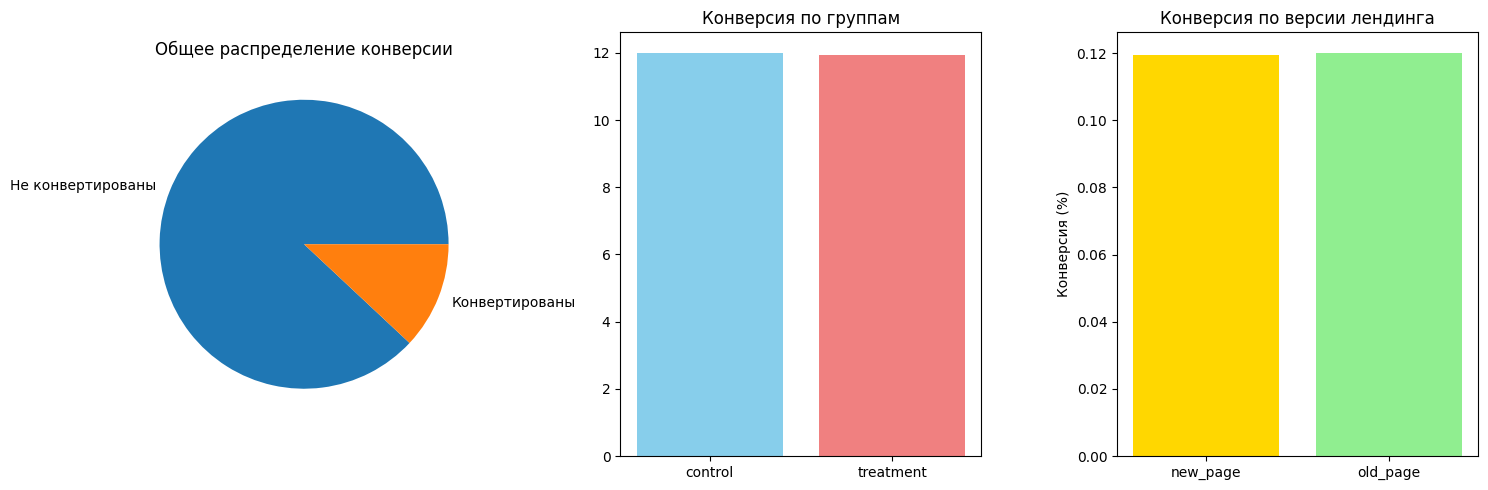

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].pie(df['converted'].value_counts(), labels=['Не конвертированы', 'Конвертированы'])
axes[0].set_title('Общее распределение конверсии')

group_conversion = df.groupby('group')['converted'].mean()
axes[1].bar(group_conversion.index, group_conversion.values * 100, color=['skyblue', 'lightcoral']) #на 100 для красоты
axes[1].set_title('Конверсия по группам')
axes[1].set_ylabel('Конверсия (%)')

# По лендингу
page_conversion = df.groupby('landing_page')['converted'].mean()
axes[2].bar(page_conversion.index, page_conversion.values, color=['lightgreen', 'gold'])
axes[2].set_title('Конверсия по версии лендинга')
axes[2].set_ylabel('Конверсия (%)')

plt.tight_layout()
plt.show()

https://sberbusiness.live/publications/cr-v-reklame-i-marketinge для лендинга 12% конверсии в целом нормально

**Проверка на однородность групп**

In [ ]:
control_group = df[df['group'] == 'control']
treatment_group = df[df['group'] == 'treatment']

In [ ]:
#По размеру
control_size = len(control_group)
treatment_size = len(treatment_group)
print('Размер контрольной группы:', control_size)
print('Размер экспериментальной группы:', treatment_size)
print('Соотношение групп:', control_size/treatment_size)

Размер контрольной группы: 147202
Размер экспериментальной группы: 147276
Соотношение групп: 0.9994975420299302


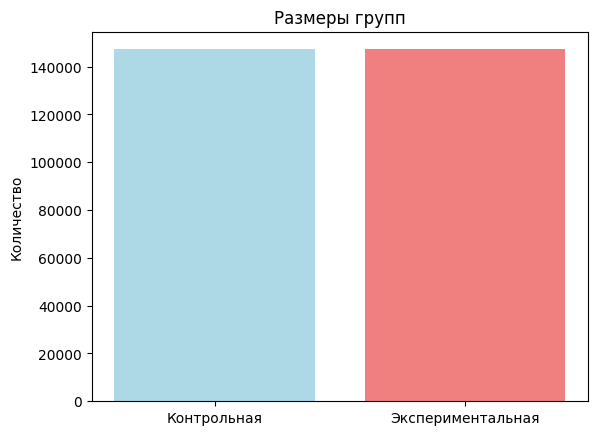

In [ ]:
control_size = len(control_group)
treatment_size = len(treatment_group)

plt.bar(['Контрольная', 'Экспериментальная'],
        [control_size, treatment_size],
        color=['lightblue', 'lightcoral'])
plt.title('Размеры групп')
plt.ylabel('Количество')
plt.show()

Размер контрольной корректной группы: 145274
Размер экспериментальной корректной группы: 145311
Соотношение групп: 0.9997453737156856


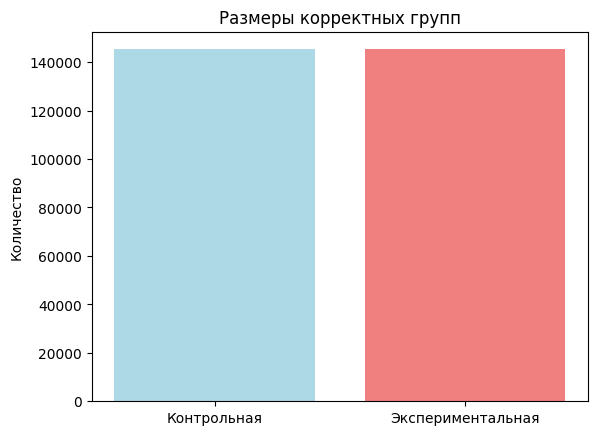

In [ ]:
# Размеры в корректных данных
control_correct = df_correct[df_correct['group'] == 'control']
treatment_correct = df_correct[df_correct['group'] == 'treatment']

control_correct_size = len(control_correct)
treatment_correct_size = len(treatment_correct)

print('Размер контрольной корректной группы:', control_correct_size)
print('Размер экспериментальной корректной группы:', treatment_correct_size)
print('Соотношение групп:', control_correct_size/treatment_correct_size)

plt.bar(['Контрольная', 'Экспериментальная'],
        [control_correct_size, treatment_correct_size],
        color=['lightblue', 'lightcoral'])
plt.title('Размеры корректных групп')
plt.ylabel('Количество')
plt.show()


In [ ]:
#По конверсии

print('Конверсия в группах')
print('Контрольная группа:', control_group['converted'].mean())
print('Экспериментальная группа:', treatment_group['converted'].mean())
print()
# Посмотрим конверсию в корректных данных
control_correct = df_correct[df_correct['group'] == 'control']
treatment_correct = df_correct[df_correct['group'] == 'treatment']

print('Конверсия в корректных данных')
print('Контрольная группа:', control_correct['converted'].mean())
print('Экспериментальная группа:', treatment_correct['converted'].mean())

Конверсия в группах
Контрольная группа: 0.12039917935897611
Экспериментальная группа: 0.11891957956489856

Конверсия в корректных данных
Контрольная группа: 0.1203863045004612
Экспериментальная группа: 0.11880724790277405


Тест Хи-квадрат Пирсона нужен для оценки однородности и сравнения различий https://sky.pro/wiki/analytics/hi-kvadrat-pirsona-tablica-kriticheskih-znachenij-dlya-analiza/
Поэтому провеедем тест хи квадрат и посмотрим на различия в конверсии


https://habr.com/ru/articles/920936/?ysclid=mj7bqel6ro896880250

In [ ]:
chi2, p_val, dof, expected = chi2_contingency(pd.crosstab(df['group'], df['converted']))
print('p_value:', p_val)
if p_val > 0.05:
    print("Группы статистически не различаются по конверсии")
else:
    print("Группы статистически различаются по конверсии")

p_value: 0.2182316121631168
Группы статистически не различаются по конверсии


#### Временной анализ

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek

In [ ]:
daily_stats = df.groupby('date').agg({
    'user_id': 'count',
    'converted': 'mean'
}).reset_index()
daily_stats.columns = ['date', 'visits', 'conversion_rate']

Посещение по дням

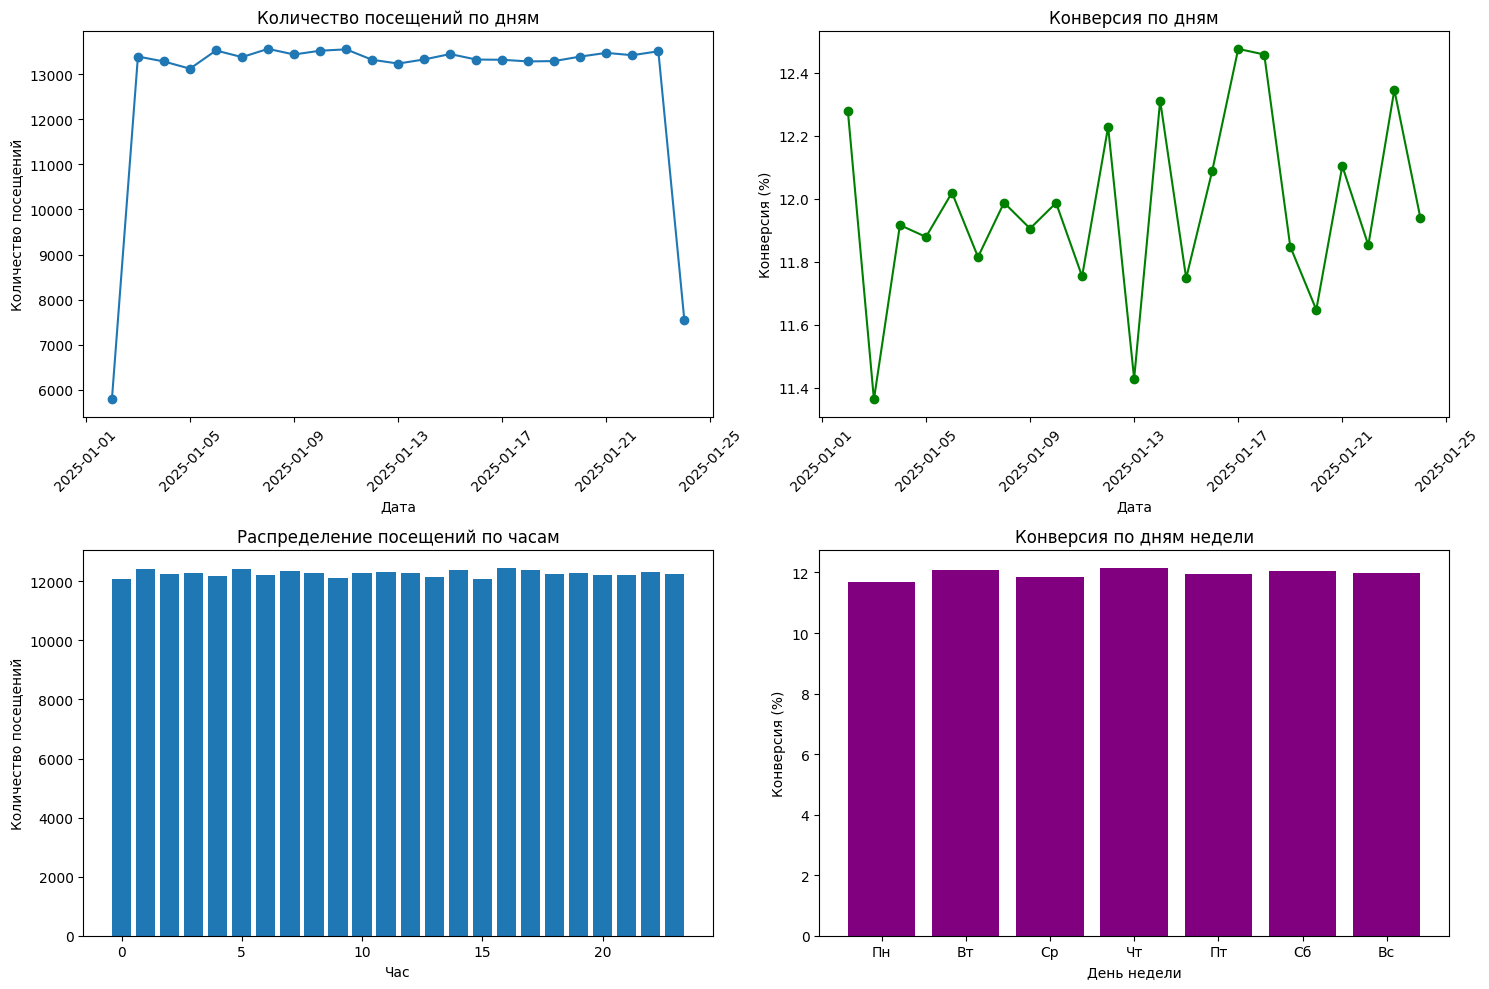

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Посещения по дням
axes[0, 0].plot(daily_stats['date'], daily_stats['visits'], marker='o')
axes[0, 0].set_title('Количество посещений по дням')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Количество посещений')
axes[0, 0].tick_params(axis='x', rotation=45)


# Конверсия по дням
axes[0, 1].plot(daily_stats['date'], daily_stats['conversion_rate'] * 100,
                marker='o', color='green')
axes[0, 1].set_title('Конверсия по дням')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Конверсия (%)')
axes[0, 1].tick_params(axis='x', rotation=45)


# Посещения по часам
hourly_visits = df.groupby('hour').size()
axes[1, 0].bar(hourly_visits.index, hourly_visits.values)
axes[1, 0].set_title('Распределение посещений по часам')
axes[1, 0].set_xlabel('Час')
axes[1, 0].set_ylabel('Количество посещений')

# Конверсия по дням недели
dow_conversion = df.groupby('day_of_week')['converted'].mean()
axes[1, 1].bar(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'],
               dow_conversion.values * 100, color='purple')
axes[1, 1].set_title('Конверсия по дням недели')
axes[1, 1].set_xlabel('День недели')
axes[1, 1].set_ylabel('Конверсия (%)')

plt.tight_layout()
plt.show()


In [ ]:
top5_visit_days = daily_stats.sort_values('visits', ascending=False).head(5)
bottom5_visit_days = daily_stats.sort_values('visits', ascending=True).head(5)

top5_conv_days = daily_stats.sort_values('conversion_rate', ascending=False).head(5)
bottom5_conv_days = daily_stats.sort_values('conversion_rate', ascending=True).head(5)

print('Топ-5 дней по посещениям:')
print(top5_visit_days)
print()

print('Топ-5 дней с наименьшими посещениями:')
print(bottom5_visit_days)
print()

print('Топ-5 дней по конверсии:')
print(top5_conv_days)
print()

print('Топ-5 дней с наименьшей конверсией:')
print(bottom5_conv_days)

Топ-5 дней по посещениям:
          date  visits  conversion_rate
6   2025-01-08   13564         0.119876
9   2025-01-11   13553         0.117539
4   2025-01-06   13528         0.120195
8   2025-01-10   13523         0.119870
21  2025-01-23   13511         0.123455

Топ-5 дней с наименьшими посещениями:
          date  visits  conversion_rate
0   2025-01-02    5783         0.122774
22  2025-01-24    7538         0.119395
3   2025-01-05   13124         0.118790
11  2025-01-13   13238         0.114292
2   2025-01-04   13284         0.119166

Топ-5 дней по конверсии:
          date  visits  conversion_rate
15  2025-01-17   13322         0.124756
16  2025-01-18   13285         0.124577
21  2025-01-23   13511         0.123455
12  2025-01-14   13329         0.123115
0   2025-01-02    5783         0.122774

Топ-5 дней с наименьшей конверсией:
          date  visits  conversion_rate
1   2025-01-03   13394         0.113633
11  2025-01-13   13238         0.114292
18  2025-01-20   13393         0

Сайт имеет исключительную стабильность


/tmp/ipython-input-1787121395.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_incorrect['timestamp'] = pd.to_datetime(df_incorrect['timestamp'])
/tmp/ipython-input-1787121395.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_incorrect['date'] = df_incorrect['timestamp'].dt.date
/tmp/ipython-input-1787121395.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

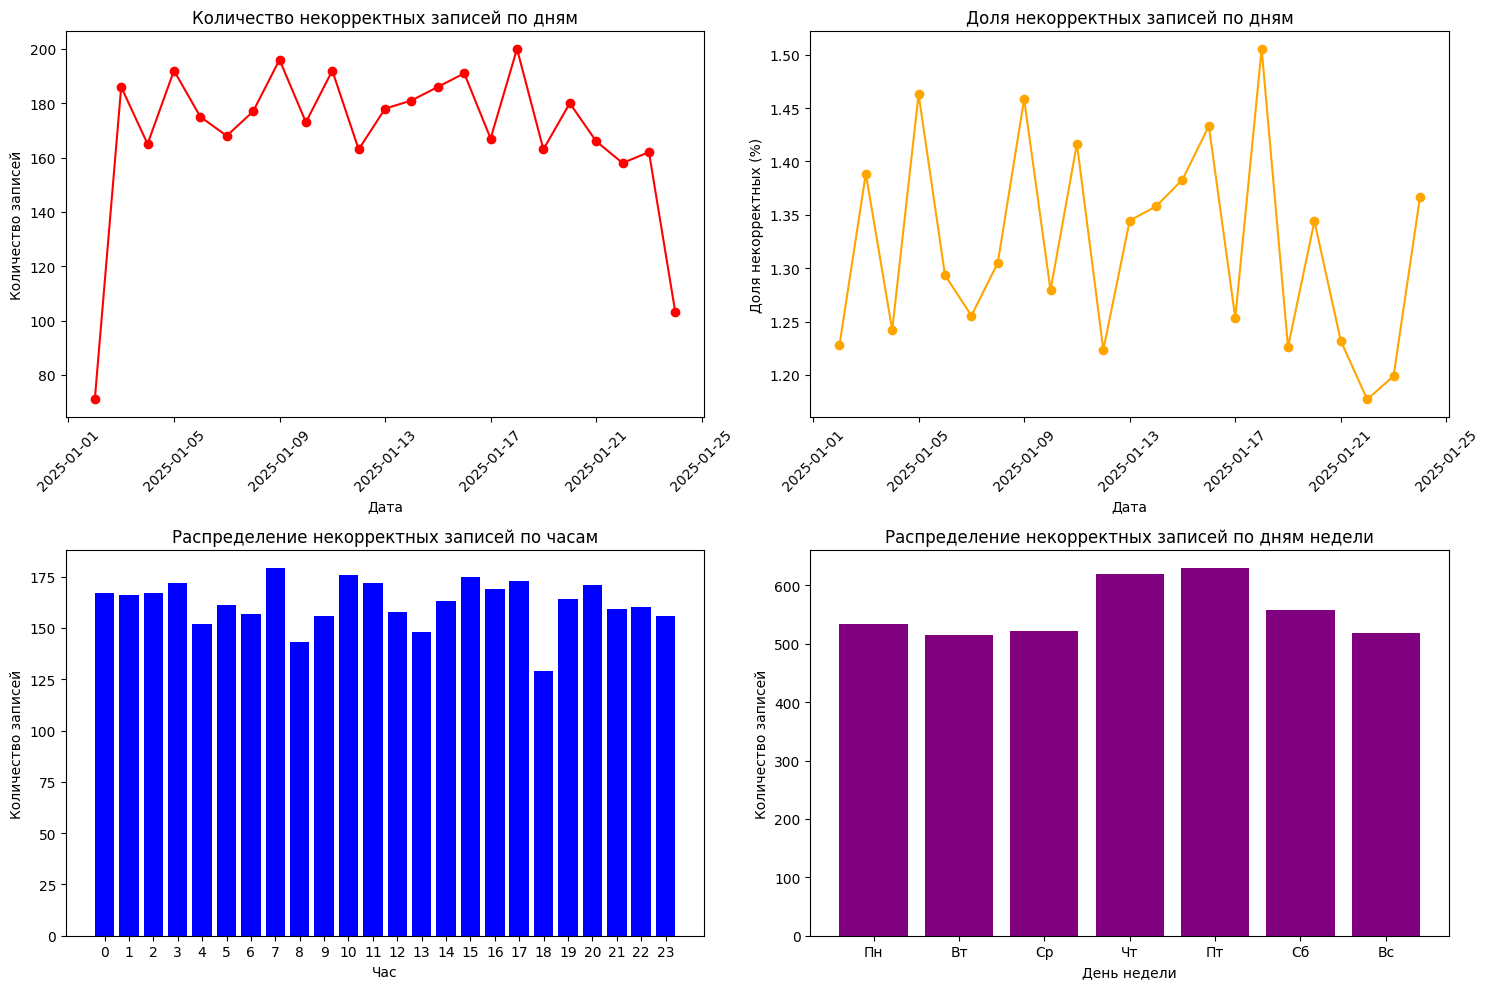

In [ ]:
df_incorrect['timestamp'] = pd.to_datetime(df_incorrect['timestamp'])
df_incorrect['date'] = df_incorrect['timestamp'].dt.date
df_incorrect['hour'] = df_incorrect['timestamp'].dt.hour
df_incorrect['day_of_week'] = df_incorrect['timestamp'].dt.dayofweek


# некоректные записи по дням
daily_incorrect = df_incorrect.groupby('date').size().reset_index(name='incorrect_count')
daily_incorrect['date'] = pd.to_datetime(daily_incorrect['date'])

# Общее количество записей по дням
daily_total = df.groupby('date').size().reset_index(name='total_count')
daily_total['date'] = pd.to_datetime(daily_total['date'])

#расчета доли для 2 графика
daily_merged = pd.merge(daily_incorrect, daily_total, on='date', how='left')
daily_merged['incorrect_percentage'] = (daily_merged['incorrect_count'] / daily_merged['total_count']) * 100

# некорректные записи по часам
hourly_incorrect = df_incorrect.groupby('hour').size()

# нНекорректные записи по дням недели
weekday_incorrect = df_incorrect.groupby('day_of_week').size()
weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

# Создаем графики
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# График 1
axes[0, 0].plot(daily_merged['date'], daily_merged['incorrect_count'], marker='o', color='red')
axes[0, 0].set_title('Количество некорректных записей по дням')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Количество записей')
axes[0, 0].tick_params(axis='x', rotation=45)

# График 2
axes[0, 1].plot(daily_merged['date'], daily_merged['incorrect_percentage'],
                marker='o', color='orange')
axes[0, 1].set_title('Доля некорректных записей по дням')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Доля некорректных (%)')
axes[0, 1].tick_params(axis='x', rotation=45)

# График 3
axes[1, 0].bar(hourly_incorrect.index, hourly_incorrect.values, color='blue')
axes[1, 0].set_title('Распределение некорректных записей по часам')
axes[1, 0].set_xlabel('Час')
axes[1, 0].set_ylabel('Количество записей')
axes[1, 0].set_xticks(range(0, 24))

# График 4
axes[1, 1].bar(weekday_names, weekday_incorrect.values, color='purple')
axes[1, 1].set_title('Распределение некорректных записей по дням недели')
axes[1, 1].set_xlabel('День недели')
axes[1, 1].set_ylabel('Количество записей')

plt.tight_layout()
plt.show()


**Итоговые выводы:**

18 января: входит в топ по конверсии (12.46%) и количеству ошибок (200 записей) — необходима проверка корректности данных для этого дня

11 января: высокие посещения (13.5k) и значительное количество ошибок (192)

Рабочие часы: пики ошибок совпадают с пиковой нагрузкой

Стабильность данных, нет резких колебаний

**А/А тест**

Тест заключается в том, что обе группы видят одинаковую версию страницы. В нашем случае провести такой тест возможно, поскольку есть 3893 неверных комбинаций

Те рассматриваем контрольную и эксперементальную группу, которые видят новую страницу и контрольную и эксперементальную группу, которые видят старую страницу

Но в таком случае выборки будут неоднородны (размер выборок отличается в разы) и необходимо провести еще другие "телодвижения" для проведения теста

#### Формирование гипотез и выбор статистического теста

**Нулевая гипотеза (H0)** - Новая версия лендинга НЕ влияет на конверсию (Конверсия в экспериментальной группе <= Конверсии в контрольной группе)

**Альтернативная гипотеза (H1)** - Новая версия лендинга УВЕЛИЧИВАЕТ конверсию (Конверсия в экспериментальной группе > Конверсии в контрольной группе)

Данные (converted) бинарны => не нормально распределены

Выбираем статистический тест - **Z-test**

*   Имеем две независимые выборки
*   Метрика - бинарная (конверсия/не конверсия)
*   Размеры выборок достаточно большие (>30)
*   Z-тест оптимален для сравнения пропорций в больших выборках. Z-тест предназначен для сравнения пропорций — он проверяет гипотезу о равенстве долей в двух независимых выборках. В нашем случае cr как раз таки в долях



https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html  (оттуда про alternative, и что наша alternative = 'larger' для проверки, что первая группа(эксперементальная) лучше второй (контрольной)

In [ ]:
#для корректных данных

n_control_correct = len(control_correct) #кол-во пользователей в этих группах
n_treatment_correct = len(treatment_correct)

converted_control_correct = control_correct['converted'].sum() #сколько пользователей конверт. (или же кол-во успешных конверсий)
converted_treatment_correct = treatment_correct['converted'].sum()

count = [converted_treatment_correct, converted_control_correct] #кол-во успешных конверсий
nobs = [n_treatment_correct, n_control_correct] #размеры выборок

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print('Z-статистика:', z_stat)
print('P-value:', p_value)

Z-статистика: -1.3116075339133115
P-value: 0.905173705140591


In [ ]:
#для всех данных

n_control = len(control_group)
n_treatment = len(treatment_group)

converted_control = control_group['converted'].sum() #сколько пользователей конверт. (или же кол-во успешных конверсий)
converted_treatment = treatment_group['converted'].sum()

count = [converted_treatment, converted_control] #кол-во успешных конверсий
nobs = [n_treatment, n_control] #размеры выборок

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print('Z-статистика:', z_stat)
print('P-value:', p_value)

Z-статистика: -1.2369217547321678
P-value: 0.8919419336512124


p_value > 0.05 поэтому НЕ ОТКЛОНЯЕМ нулевую гипотезу. Те новая версия лендинга НЕ показывает статистически значимого улучшения

но при этом z stat < 0 -> Экспериментальная группа показывает худший результат


#### Bootstrap

Bootstrap

mean_diff: -0.0015748384749098678
95% доверительный интервал: -0.003953541332196218 0.0008367687946529212


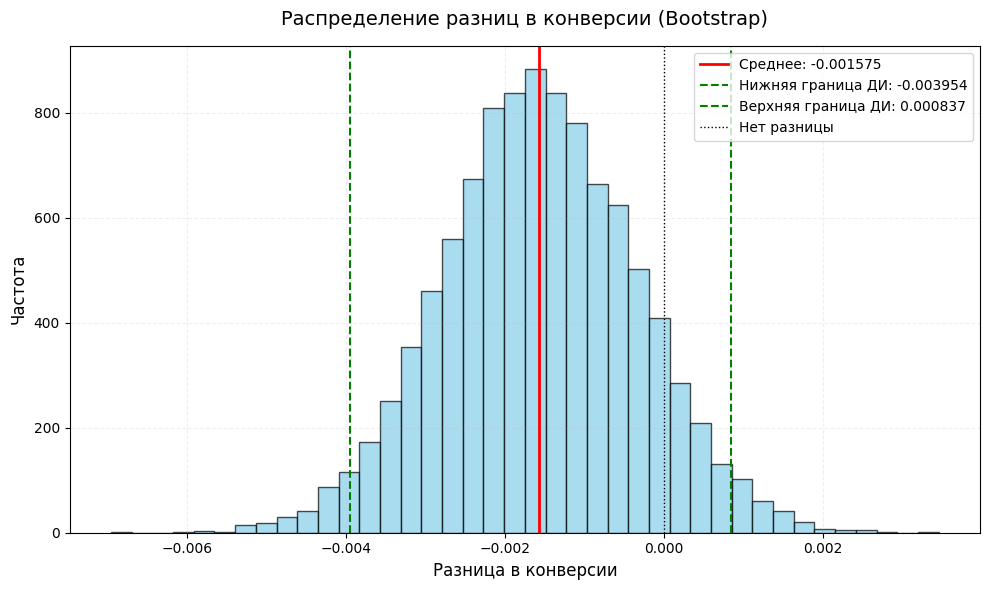

In [ ]:
def bootstrap_diff(data1, data2, n_bootstrap=10000): #Bootstrap для оценки разницы в конверсии
    n1, n2 = len(data1), len(data2)
    diffs = []

    for _ in range(n_bootstrap):
        sample1 = np.random.choice(data1, n1, replace=True)
        sample2 = np.random.choice(data2, n2, replace=True)
        diffs.append(sample2.mean() - sample1.mean())

    return np.array(diffs)

control_data = control_correct['converted'].values
treatment_data = treatment_correct['converted'].values

bootstrap_diffs = bootstrap_diff(control_data, treatment_data)

ci_lower, ci_upper = np.percentile(bootstrap_diffs, [2.5, 97.5])
mean_diff = bootstrap_diffs.mean()

print('mean_diff:', mean_diff)
print('95% доверительный интервал:', ci_lower, ci_upper)

plt.figure(figsize=(10, 6))
plt.hist(bootstrap_diffs, bins=40, edgecolor='black', alpha=0.7, color='skyblue')

plt.axvline(mean_diff, color='red', linewidth=2, label=f'Среднее: {mean_diff:.6f}')
plt.axvline(ci_lower, color='green', linestyle='--', label=f'Нижняя граница ДИ: {ci_lower:.6f}')
plt.axvline(ci_upper, color='green', linestyle='--', label=f'Верхняя граница ДИ: {ci_upper:.6f}')
plt.axvline(0, color='black', linestyle=':', linewidth=1, label='Нет разницы')

plt.title('Распределение разниц в конверсии (Bootstrap)', fontsize=14, pad=15)
plt.xlabel('Разница в конверсии', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

Средняя разница: -0.001561 (или -0.1561%)
Это означает, что в тестовой группе (treatment) конверсия в среднем на 0.1561% ниже, чем в контрольной группе

Диапазон: [-0.003926, 0.000796] или [-0.3926%, +0.0796%]
Ключевой факт: интервал включает ноль (0 находится между -0.003926 и 0.000796)

Тк ДИ не полностью выше 0 (те нет статистически значимого улучшения) и ДИ не полностью ниже 0 (те нет статистически значимого ухудшения), а ДИ включает 0, что означает отсутсвие статистически значимой разницы


**Вывод: Разница между группами статистически не значима**

#### Рекомендации и бизнес-инсайты

Основные выводы

1.   Статистическая значимость (z-test: p_value > 0.05, bootstrap: ди включает 0) -> **статистически не значимо**
2.   Размер эффекта (z-stat < 0, bootstrap: средняя разница -0,1561%) -> **эффект неположительный**
3.   Качество данных (Некорректных комбинаций 3893 (1,32%) -> **присутствуют технические проблемы в проведении теста**






Рекомендации



1.   Технические улучшения:

*   Исправить баг распределения пользователей по версиям лендинга
*   Мониторинг корректности A/B тестов
*   Делать проверки на соответствие group и landing_page

2.   Дальнейшие действия:

*   НЕ РЕКОМЕНДУЕМ внедрять новую версию лендинга, поскольку p_value > 0.05
*   Эффект статистически не значим
*   Текущие изменения не приносят значимой выгоды. Следует рассмотреть другие изменения и сфокусироваться на других улучшениях для увеличения конверсии
3.   Временные паттерны

*   Сохранять стабильность
*   Сосредоточиться на привлечение клиентов
*   Проанализировать критические точки





### Часть 2. Проверка гипотез методами математической статистики

В этой части группового проекта вам предстоит самим выбрать предметную область, а также самим получить датасет или датасеты, с которыми вы будете работать.

С точки зрения источников данных у вас есть две опции: вы можете найти ваш датасет — или 2-3 датасета в случае необходимости — на сайте [UCI Machine Learning Repository](https://archive.ics.uci.edu/) (брать датасеты необходимо именно с этого сайта); либо же вторая опция — можно собрать датасет/датасеты вручную с помощью средств Parsing'a и API. Допускается использование и комбинации этих двух опций. В любом случае, *каждый* используемый вами датасет должен (до этапа EDA) содержать **не менее 2000 строк** и **не менее 8 признаков**.




После получения датасетов вам следует:
- провести EDA с осмысленными визуализациями и качественным поиском первичных закономерностей;
- на основе проделенного EDA сформулировать **минимум три чёткие, содержательные гипотезы**;
- подобрать и реализовать **минимум три различных статистических теста** для проверки сформулированных раннее гипотез, причём каждый тест должен быть обязательно обоснован (различные статистические тесты в нашем случае означает, что статистические критерии для этих тестов должны быть разными);
- корректно и полно проинтерпретировать полученные результаты и сформулировать итоговые выводы.

**Важно:** вы должны очень ответственно подойти к выбору датасета, так как гипотезы должны быть *не случайными*, а логически вытекающими из осуществленного EDA и, кроме того, имеющими реальный интерес для изучения и проверки с точки зрения бизнес-составляющей. В случае если по одному датасету у вас не получается сформировать 3 достаточно осмысленных гипотезы — разрешается использовать суммарно вплоть до 3 датасетов. В таком случае, все эти датасеты должны иметь какую-то связь между собой.

### Общие требования к проекту

В качестве результата выполнения группового проекта ваша команда должна получить презентацию и защитить ее перед комиссией. Наличие репозитория с кодом на GitHub является необязательным условием, но приветствуется.

Оформление презентации остаётся полностью на ваше усмотрение, но помните, что результат должен быть релевантен для демонстрации бизнес-заказчику — комиссию, принимающую вашу работу, правильнее всего воспринимать именно в таком качестве. Например, вставлять в презентацию строчки кода или злоупотреблять скринами блокнота не рекомендуется.

С точки зрения концепции выполнения проекта — вам необходимо принять на себя роль дата-аналитиков: продемонстрировать способность грамотно работать с экспериментальными статистическими данными, что включает в себя проверку корректности проведения и интерпретацию результатов построенного A/B-тестирования, правильную формулировку гипотез, выбор подходящих статистических методов, моделей и их параметров, а также построение итоговых выводов из анализа — и исследователей: уметь выбирать релевантный датасет, проводить содержательный EDA, находить закономерности и превращать их в осмысленные статистические гипотезы для проверки. А в конце, конечно, — презентовать всю эту красоту в понятном виде потенциальному заказчику.

Подчеркнем отдельно: ваша задача — не просто провести тесты и сделать какие-то выводы из них, но разобраться в данных, изучить их природу, выявить реальные зависимости и инсайты, а также на основе проделанного анализа показать, почему эти находки важны для бизнеса или для выбранного контекста датасета. Разумеется, чем интереснее выбранная вами предметная область, чем осмысленнее сформулированные гипотезы и чем глубже будет проведенное вами исследование — тем выше окажется итоговое качество проекта и тем выше он будет оценён!

### Полезные замечания и советы

- Графики и визуализации помогают наглядно доносить информацию, а также анализировать данные
- Формулируйте гипотезы *после* EDA. Не придумывайте гипотезы "вслепую", сначала погрузитесь в данные, найдите закономерности, паттерны и лишь затем переходите к выделению статически проверяемых гипотез
- Не забывайте о прикладной значимости ваших проектов — ваш анализ должен быть полезен потенциальному заказчику
- Используйте разные подходы к проверке гипотез. Ищите способы усилить ваши тесты. Применяйте новые методы и идеи, а затем рассказывайте про них нам. Не бойтесь эксперементировать! Это будет только поощряться :)
